# Sky-position scan with NITRATES

This notebook performs a **minimal non-imaging sky scan** over a few trial positions and computes $\sqrt{TS}$ at each position.

## What this notebook does
1. Load the bundled test dataset from `tests/nitrates_resp_dir` (or `NITRATES_RESP_DIR` if already set).
2. Build source + background likelihood objects.
3. Scan a small set of sky positions around a reference RA/Dec.
4. Profile over signal amplitude $A$ at each position and compute:

$$\sqrt{TS} = \sqrt{2(\mathrm{NLLH}_{\mathrm{bkg}} - \mathrm{NLLH}_{\mathrm{sig+bkg}})}$$

5. Show a sky localization map

In [12]:
import os
import warnings
import io
import contextlib

# ── macOS kernel-crash prevention ────────────────────────────────────────────
# These MUST be set before ANY library that links OpenMP / MKL / Accelerate
# is imported.  The root cause is that macOS loads multiple OpenMP runtimes
# simultaneously (libomp from conda-forge + libiomp5 from Intel/MKL), which
# corrupts Numba's JIT thread pool and causes a hard segfault.
#
# Key fix: switch Numba away from OpenMP entirely → use its own work-queue.
os.environ['NUMBA_THREADING_LAYER']    = 'workqueue'   # ← the essential fix
os.environ['NUMBA_NUM_THREADS']        = '1'
os.environ['OMP_NUM_THREADS']          = '1'
os.environ['MKL_NUM_THREADS']          = '1'
os.environ['OPENBLAS_NUM_THREADS']     = '1'
os.environ['VECLIB_MAXIMUM_THREADS']   = '1'           # macOS Accelerate
os.environ['KMP_DUPLICATE_LIB_OK']     = 'TRUE'        # last-resort guard
# ─────────────────────────────────────────────────────────────────────────────

import logging
from pathlib import Path
import numpy as np
from astropy.io import fits
from nitrates.lib import (
    get_conn,
    get_info_tab,
    mask_detxy,
    convert_radec2thetaphi,
    convert_theta_phi2radec,
)
from nitrates.response import RayTraces
from nitrates.models import (
    Cutoff_Plaw_Flux,
    Source_Model_InOutFoV,
    CompoundModel,
    Sig_Bkg_Model,
    get_eflux_from_model,
)
from nitrates.llh_analysis import parse_bkg_csv, LLH_webins2, NLLH_ScipyMinimize_Wjacob

# Silence verbose internal output from NITRATES, astropy and root logger.
logging.basicConfig(level=logging.ERROR)
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger('astropy').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

@contextlib.contextmanager
def suppress_output():
    """Redirect stdout/stderr to suppress print noise from NITRATES internals."""
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

# Use the explicit local response directory
resp_dir = Path('/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir').resolve()
if not resp_dir.exists():
    raise FileNotFoundError(f'NITRATES response directory not found: {resp_dir}')

os.environ['NITRATES_RESP_DIR'] = str(resp_dir)
rt_dir = resp_dir / 'ray_traces_detapp_npy'
solid_angle_dpi_path = resp_dir / 'solid_angle_dpi.npy'

print(f"Using responses from: {resp_dir}")


Using responses from: /Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir


In [13]:

trigid = '785996578_c0'
triggertime = '2025-11-28T04:22:21.610000'

# Define the literature/source sky position used throughout the tutorial.
source_ra_dec = (123, 50)

root = '/Users/samueleronchini/Desktop/nitrates_tutorial'

workdir = f'{root}/{trigid}'

In [14]:
# Trigger metadata
conn = get_conn(workdir + '/results.db')
info_tab = get_info_tab(conn)
trig = info_tab['trigtimeMET'][0]

# Event data and detector mask
ev_data = fits.open(workdir + '/filter_evdata.fits')[1].data
dmask = fits.open(workdir + '/detmask.fits')[0].data
mask_vals = mask_detxy(dmask, ev_data)
bl_dmask = dmask == 0.0

# Basic time/energy cuts
t_start = trig - 20
t_end = trig + 20
bl_ev = (
    (ev_data['EVENT_FLAGS'] < 1)
    & (ev_data['ENERGY'] <= 500.0)
    & (ev_data['ENERGY'] >= 14.0)
    & (mask_vals == 0.0)
    & (ev_data['TIME'] <= t_end)
    & (ev_data['TIME'] >= t_start)
)
filtered_ev_data = ev_data[bl_ev]
print(f"Selected {len(filtered_ev_data)} events over {t_end - t_start:.1f} s")


Selected 169204 events over 40.0 s


In [15]:
# Build the analysis energy bins in keV.
# `ebins0` contains the lower edge of each bin and `ebins1` the matching upper edge.
ebins0 = np.array([15.0, 24.0, 35.0, 48.0, 64.0])
ebins0 = np.append(ebins0, np.logspace(np.log10(84.0), np.log10(500.0), 5 + 1))[:-1]
ebins0 = np.round(ebins0, decimals=1)[:-1]
ebins1 = np.append(ebins0[1:], [350.0])

# Load the spacecraft attitude table and select the quaternion closest to the trigger time.
# This quaternion describes how the instrument was oriented on the sky at that moment.
with suppress_output():
    attfile = fits.open(workdir + '/attitude.fits')[1].data
att_ind = np.argmin(np.abs(attfile['TIME'] - trig))
att_quat = attfile['QPARAM'][att_ind]

# Convert the source sky coordinates (RA, Dec) into instrument coordinates (theta, phi).
# The source response must be evaluated in the detector frame, not directly in RA/Dec.
theta, phi = convert_radec2thetaphi(*source_ra_dec, att_quat)

# Configure the spectral model parameters used as the initial source hypothesis.
# `A` is the normalization, `gamma` the photon index, and `Epeak` the cutoff/peak scale in keV.
flux_params = {'A': 1.0, 'gamma': 0.5, 'Epeak': 1e2}
flux_mod = Cutoff_Plaw_Flux(E0=100.0)

# Load the precomputed ray traces that encode detector shadowing across the field of view.
# Build the non-imaging source model using the spectral model, energy bins, detector mask,
# ray traces, and the response tables bundled with the tutorial dataset.
with suppress_output():
    rt_obj = RayTraces(rt_dir)
    sig_mod = Source_Model_InOutFoV(
        flux_mod,
        [ebins0, ebins1],
        bl_dmask,
        rt_obj,
        use_deriv=True,
        resp_tab_dname=resp_dir/'resp_tabs_ebins',
        comp_flor_resp_dname=resp_dir/'comp_flor_resps',
        hp_flor_resp_dname=resp_dir/'hp_flor_resps',
    )

# Apply the instrument-frame sky position and spectral parameters to the source model.
sig_mod.set_theta_phi(theta, phi)
sig_mod.set_flux_params(flux_params)

# Print a compact summary so we can verify the selected attitude sample and derived geometry.
print(f"Pointing quaternion index: {att_ind}")
print(f"Theta/Phi (deg): {theta:.3f}, {phi:.3f}")


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(45.0, 54.0)
35.59031462549889
35.59031462549889
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_45.0_.fits
Pointing quaternion index: 175
Theta/Phi (deg): 52.335, 125.590


This cell prepares the source/background setup and **chooses the analysis time bin from** time_seeds.csv.

1. Loads attitude at trigger time and keeps the reference sky position.
2. Reads time_seeds.csv from the working directory.
3. Selects the best temporal seed (priority: snr, then TS, then $\sqrt{TS}$).
4. Converts the selected seed to absolute interval $[t_0, t_1]$.
5. Loads bkg_estimation.csv and extracts background parameters at the interval midpoint.
6. Builds reusable likelihood/model objects with the selected time window.

After this cell, all sky-position scans use the same best temporal bin from the seed file.

In [16]:
# --- Build source model ingredients and background model ---
# Attitude quaternion nearest trigger (needed for RA/Dec -> theta/phi conversion).
import glob
import pandas as pd

with suppress_output():
    att = fits.open(resp_dir / 'attitude.fits')[1].data
att_idx = int(np.argmin(np.abs(att['TIME'] - trig)))
att_quat = att['QPARAM'][att_idx]

# Reference source position (can be changed if desired).
ra_ref, dec_ref = source_ra_dec[0], source_ra_dec[1]

# Choose analysis time bin from time_seeds.csv (best seed).
time_seeds_path = Path(workdir) / 'time_seeds.csv'
if not time_seeds_path.exists():
    raise FileNotFoundError(f'time_seeds.csv not found: {time_seeds_path}')

time_seeds_df = pd.read_csv(time_seeds_path)
dur_col = 'duration' if 'duration' in time_seeds_df.columns else ('dur' if 'dur' in time_seeds_df.columns else None)
if dur_col is None:
    raise KeyError("time_seeds.csv must contain 'duration' (or 'dur')")

# Prefer full-rates ranking if present.
if 'snr' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['snr'].astype(float).idxmax()
elif 'TS' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['TS'].astype(float).idxmax()
elif 'sqrtTS' in time_seeds_df.columns:
    best_seed_idx = time_seeds_df['sqrtTS'].astype(float).idxmax()
else:
    raise KeyError("time_seeds.csv must contain one ranking column among: 'snr', 'TS', 'sqrtTS'")

best_seed = time_seeds_df.loc[best_seed_idx]
dur_best = float(best_seed[dur_col])

if 'time' in time_seeds_df.columns:
    t0 = float(best_seed['time'])
elif 'dt' in time_seeds_df.columns:
    t0 = float(trig) + float(best_seed['dt'])
else:
    raise KeyError("time_seeds.csv must contain either 'time' or 'dt'")
t1 = t0 + dur_best

print(
    f"Selected best time seed from {time_seeds_path.name}: "
    f"t0-trig={t0 - float(trig):+.3f} s, dur={dur_best:.3f} s"
)

# Spectral shape: take gamma/Epeak from split-rates results (same or nearest time bin).
split_files = sorted(glob.glob(str(Path(workdir) / 'rates_llh_res_*.csv')))
if not split_files:
    raise FileNotFoundError('No split-rate files found (rates_llh_res_*.csv). Run split-rates first.')

split_df = pd.concat([pd.read_csv(f) for f in split_files], ignore_index=True)
if 'gamma' not in split_df.columns or 'Epeak' not in split_df.columns:
    raise KeyError("Split-rate table must contain 'gamma' and 'Epeak' columns")

# Match split-rates row to selected time seed.
cand = split_df.copy()

# Prefer exact match by timeID if available in both tables.
if 'timeID' in cand.columns and 'timeID' in best_seed.index:
    cand = cand[cand['timeID'].astype(float) == float(best_seed['timeID'])]

# If timeID match is empty/not available, use nearest in (time, duration).
if len(cand) == 0:
    if 'time' in split_df.columns and 'dur' in split_df.columns:
        tmp = split_df.copy()
        tmp['_metric'] = (tmp['time'].astype(float) - float(t0)).abs() + (tmp['dur'].astype(float) - float(dur_best)).abs()
        min_metric = float(tmp['_metric'].min())
        cand = tmp[tmp['_metric'] == min_metric].copy()
    else:
        cand = split_df.copy()

# Choose highest-significance split-rate row among candidates.
rank_col = 'TS' if 'TS' in cand.columns else ('sqrtTS' if 'sqrtTS' in cand.columns else None)
if rank_col is not None:
    best_split = cand.loc[cand[rank_col].astype(float).idxmax()]
else:
    best_split = cand.iloc[0]

gamma_best = float(best_split['gamma'])
epeak_best = float(best_split['Epeak'])

flux_mod = Cutoff_Plaw_Flux(E0=100.0)
flux_shape = {'A': 1.0, 'gamma': gamma_best, 'Epeak': epeak_best}
print(f"Using split-rates spectral shape: gamma={gamma_best:.3f}, Epeak={epeak_best:.2f} keV")

# Background model and parameters at analysis time midpoint.
bkg_csv_path = Path(workdir) / 'bkg_estimation.csv'

with suppress_output():
    bkg_df, bkg_name, _, bkg_mod, ps_mods = parse_bkg_csv(
        bkg_csv_path,
        np.load(solid_angle_dpi_path),
        ebins0,
        ebins1,
        bl_dmask,
        rt_dir,
    )

tmid = 0.5 * (t0 + t1)
bkg_row = bkg_df.iloc[np.argmin(np.abs(bkg_df['time'] - tmid))]

# Some background CSV files store columns with a prefix (e.g. "Background_bkg_rate_0")
# while model parameter names may be unprefixed (e.g. "bkg_rate_0").
def _get_bkg_value(row, pname, prefix):
    if pname in row.index:
        return row[pname]

    pref_name = f"{prefix}{pname}" if prefix else pname
    if pref_name in row.index:
        return row[pref_name]

    if pname.startswith('Background_'):
        no_pref = pname[len('Background_'):]
        if no_pref in row.index:
            return row[no_pref]

    raise KeyError(f"Background parameter '{pname}' not found in CSV columns")

bkg_params = {p: _get_bkg_value(bkg_row, p, bkg_name) for p in bkg_mod.param_names}

# Reusable objects that do not depend on trial sky position.
with suppress_output():
    rt_obj = RayTraces(rt_dir)
llh = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
llh.set_time(t0, t1)

print('Source/background setup complete.')


Selected best time seed from time_seeds.csv: t0-trig=-1.024 s, dur=4.096 s
Using split-rates spectral shape: gamma=-0.100, Epeak=411.33 keV
Source/background setup complete.


### `eval_sky_position`

This helper evaluates one trial sky coordinate and returns the detection significance for that point.

1. Receives trial $(\mathrm{RA},\mathrm{Dec})$ and clips/wraps values to valid ranges.
2. Converts sky coordinates to instrument coordinates $(\theta,\phi)$ using the trigger-time attitude.
3. Builds a trial source model at that sky position with fixed spectral shape.
4. Combines source + background models and attaches them to the likelihood object.
5. Computes background-only NLLH with $A\approx 0$.
6. Profiles the likelihood over amplitude `A` (all other parameters fixed).
7. Computes $\sqrt{TS}=\sqrt{2(\mathrm{NLLH}_{\mathrm{bkg}}-\mathrm{NLLH}_{\mathrm{best}})}$ and returns a result dictionary.

Returned fields include position, best-fit amplitude, NLLH values, and `sqrtTS`.

In [17]:
# --- Helper: evaluate one sky position and return sqrtTS ---
def eval_sky_position(ra_deg: float, dec_deg: float):
    """
    Evaluate one trial (RA, Dec):
    1) Convert to instrument coordinates (theta, phi).
    2) Build source+background model with fixed spectral shape.
    3) Profile likelihood over amplitude A only.
    4) Compute sqrtTS relative to background-only hypothesis.
    """
    # Keep values in physical ranges for robust scanning.
    ra_deg = float(ra_deg % 360.0)
    dec_deg = float(np.clip(dec_deg, -89.0, 89.0))

    # Sky -> instrument frame.
    theta, phi = convert_radec2thetaphi(ra_deg, dec_deg, att_quat)

    # Build trial source model at this sky location.
    with suppress_output():
        sig_mod = Source_Model_InOutFoV(
            flux_mod,
            [ebins0, ebins1],
            bl_dmask,
            rt_obj,
            use_deriv=True,
            resp_tab_dname=resp_dir / 'resp_tabs_ebins',
            comp_flor_resp_dname=resp_dir / 'comp_flor_resps',
            hp_flor_resp_dname=resp_dir / 'hp_flor_resps',
        )
    sig_mod.set_theta_phi(float(theta), float(phi))
    sig_mod.set_flux_params(flux_shape)

    # Combine source + background and set parameters.
    sig_bkg = Sig_Bkg_Model(bl_dmask, sig_mod, bkg_mod, use_deriv=True)
    sig_bkg.set_bkg_params(bkg_params)
    sig_bkg.set_sig_params({
        'A': 1.0,
        'gamma': float(flux_shape['gamma']),
        'Epeak': float(flux_shape['Epeak']),
        'theta': float(theta),
        'phi': float(phi),
    })

    # Attach model to LLH object.
    llh.set_model(sig_bkg)

    # Background-only NLLH (A ~ 0).
    nllh_bkg = -float(llh.get_logprob({'A': 1e-10}))

    # Profile over A with all other parameters fixed.
    miner = NLLH_ScipyMinimize_Wjacob('')
    miner.set_llh(llh)
    miner.set_fixed_params(miner.param_names, fixed=True)
    miner.set_fixed_params(['A'], fixed=False)

    bf_vals, nllh_vals, _ = miner.minimize()
    A_best = float(np.atleast_1d(bf_vals[0])[0])
    nllh_best = float(nllh_vals[0])

    # sqrtTS from profile likelihood ratio.
    sqrt_ts = float(np.sqrt(max(2.0 * (nllh_bkg - nllh_best), 0.0)))

    return {
        'ra': ra_deg,
        'dec': dec_deg,
        'theta': float(theta),
        'phi': float(phi),
        'A_best': A_best,
        'nllh_bkg': nllh_bkg,
        'nllh_best': nllh_best,
        'sqrtTS': sqrt_ts,
    }


In [18]:
import pandas as pd

# --- Define a 3×3 grid of trial sky positions around the reference point ---
offsets = np.linspace(-35, 35, 4)
trial_positions = [
    (ra_ref + dra, dec_ref + ddec)
    for ddec in offsets
    for dra in offsets
]

rows = []
for ra_i, dec_i in trial_positions:
    try:
        rows.append(eval_sky_position(ra_i, dec_i))
    except Exception as e:
        # If one position is unsupported by response coverage, continue scanning others.
        rows.append({
            'ra': float(ra_i),
            'dec': float(dec_i),
            'theta': np.nan,
            'phi': np.nan,
            'A_best': np.nan,
            'nllh_bkg': np.nan,
            'nllh_best': np.nan,
            'sqrtTS': np.nan,
            'error': str(e),
        })

scan_df = pd.DataFrame(rows)
scan_df = scan_df.sort_values('sqrtTS', ascending=False, na_position='last').reset_index(drop=True)

display_cols = ['ra', 'dec', 'A_best', 'sqrtTS', 'nllh_bkg', 'nllh_best']
print('Sky scan results (sorted by sqrtTS):')
display(scan_df[display_cols])

if scan_df['sqrtTS'].notna().any():
    best = scan_df.loc[scan_df['sqrtTS'].idxmax()]
    print(
        f"Best trial position: RA={best['ra']:.3f}, Dec={best['dec']:.3f}, "
        f"sqrtTS={best['sqrtTS']:.3f}, A_best={best['A_best']:.3e}"
    )
else:
    print('No valid sky points were evaluated.')


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(63.0, 72.0)
33.717838404782015
11.282161595217985
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_63.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_72.0_phi_0.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_72.0_phi_15.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(36.0, 45.0)
21.476676602570535
23.523323397429465
max rt: 11579.5469
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_15.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitra

,ra,dec,A_best,sqrtTS,nllh_bkg,nllh_best
0,88.000000,15.000000,0.010049,16.570776,51767.325646,51630.030332
1,158.000000,38.333333,0.006979,16.276956,51767.325645,51634.855998
2,111.333333,15.000000,0.006873,16.210564,51767.325645,51635.934451
3,88.000000,85.000000,0.006788,15.747367,51767.325645,51643.335867
4,111.333333,85.000000,0.006873,15.540036,51767.325645,51646.579283
5,134.666667,61.666667,0.008508,15.536782,51767.325646,51646.629841
6,158.000000,61.666667,0.007042,15.471196,51767.325645,51647.646686
7,158.000000,85.000000,0.006715,15.458336,51767.325645,51647.845566
8,158.000000,15.000000,0.005905,15.428516,51767.325645,51648.306096
9,134.666667,85.000000,0.006800,15.363699,51767.325645,51649.304018


Best trial position: RA=88.000, Dec=15.000, sqrtTS=16.571, A_best=1.005e-02


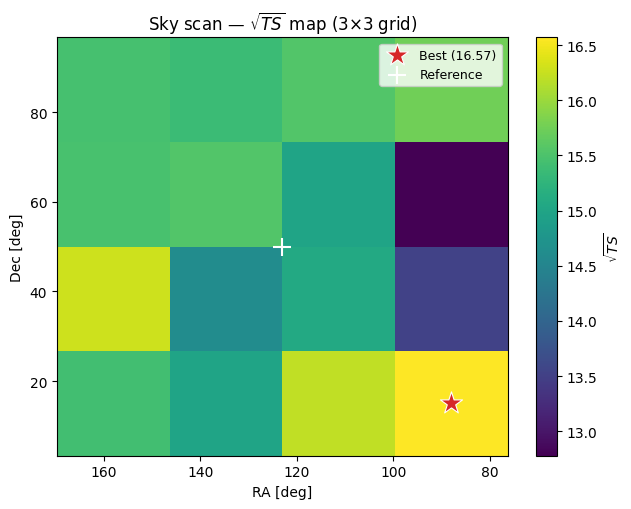

In [19]:
# --- 2D map: sqrtTS on the RA/Dec grid ---
import matplotlib.pyplot as plt
import numpy as np

valid = scan_df['sqrtTS'].notna()
if valid.any():
    df_v = scan_df.loc[valid].copy()

    # Reconstruct the 2D grid (RA increases left → invert x-axis later)
    ra_vals  = np.sort(df_v['ra'].unique())
    dec_vals = np.sort(df_v['dec'].unique())

    grid = np.full((len(dec_vals), len(ra_vals)), np.nan)
    ra_idx  = {v: i for i, v in enumerate(ra_vals)}
    dec_idx = {v: i for i, v in enumerate(dec_vals)}
    for _, row in df_v.iterrows():
        grid[dec_idx[row['dec']], ra_idx[row['ra']]] = row['sqrtTS']

    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    im = ax.pcolormesh(
        ra_vals, dec_vals, grid,
        cmap='viridis', shading='nearest',
    )
    plt.colorbar(im, ax=ax, label=r'$\sqrt{TS}$')

    # Mark best position
    best = scan_df.loc[scan_df['sqrtTS'].idxmax()]
    ax.scatter(
        best['ra'], best['dec'],
        marker='*', s=280, color='tab:red',
        edgecolors='white', linewidths=0.8,
        zorder=5, label=f"Best ({best['sqrtTS']:.2f})",
    )

    # Mark reference position
    ax.scatter(
        [ra_ref], [dec_ref],
        marker='+', s=160, color='white',
        linewidths=1.5, zorder=5, label='Reference',
    )

    ax.set_xlabel('RA [deg]')
    ax.set_ylabel('Dec [deg]')
    ax.set_title(r'Sky scan — $\sqrt{TS}$ map (3×3 grid)')
    ax.invert_xaxis()
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No valid points to plot.')


## Notes
- This is intentionally minimal: it scans only **5 trial positions**.
- Spectral shape (`gamma`, `Epeak`) is fixed; only amplitude $A$ is profiled.
- To increase localization detail, enlarge the trial grid (more RA/Dec offsets).
- If some trial points fail, they are reported as NaN (typically response-coverage limits).

## Extra section: max TS on a joint sky + spectral grid

In this final section we do a compact **joint grid scan** over:
- sky positions (RA/Dec around the reference), and
- spectral shape parameters (`gamma`, `Epeak`).

For each grid point we:
1. Build the source model at that sky position.
2. Fix (`gamma`, `Epeak`) to trial values.
3. Profile only over amplitude `A`.
4. Compute `TS = 2(\mathrm{NLLH}_{bkg} - \mathrm{NLLH}_{sig+bkg})` and `sqrtTS`.

This is slower than the essential scan, so the default grids below are intentionally small.

In [20]:
# --- Joint sky + spectral grid scan (profile over A) ---

# Small default grids (edit these to trade speed vs detail)
ra_offsets_deg = np.array([-1.0, 0.0, 1.0])
dec_offsets_deg = np.array([-1.0, 0.0, 1.0])
gamma_grid = np.array([0.0, 0.5, 1.0])
epeak_grid = np.array([70.0, 100.0, 150.0])

# Reuse event selection and time window from previous sections
llh_joint = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
llh_joint.set_time(t0, t1)

joint_rows = []

for dra in ra_offsets_deg:
    for ddec in dec_offsets_deg:
        ra_i = float((ra_ref + dra) % 360.0)
        dec_i = float(np.clip(dec_ref + ddec, -89.0, 89.0))

        try:
            theta_i, phi_i = convert_radec2thetaphi(ra_i, dec_i, att_quat)

            # Build source model once per sky position
            with suppress_output():
                sig_mod_i = Source_Model_InOutFoV(
                    flux_mod,
                    [ebins0, ebins1],
                    bl_dmask,
                    rt_obj,
                    use_deriv=True,
                    resp_tab_dname=resp_dir / 'resp_tabs_ebins',
                    comp_flor_resp_dname=resp_dir / 'comp_flor_resps',
                    hp_flor_resp_dname=resp_dir / 'hp_flor_resps',
                )
            sig_mod_i.set_theta_phi(float(theta_i), float(phi_i))

            for g_i in gamma_grid:
                for ep_i in epeak_grid:
                    try:
                        # Fixed spectral shape for this trial point
                        trial_flux = {'A': 1.0, 'gamma': float(g_i), 'Epeak': float(ep_i)}
                        sig_mod_i.set_flux_params(trial_flux)

                        sig_bkg_i = Sig_Bkg_Model(bl_dmask, sig_mod_i, bkg_mod, use_deriv=True)
                        sig_bkg_i.set_bkg_params(bkg_params)
                        sig_bkg_i.set_sig_params({
                            'A': 1.0,
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                        })

                        llh_joint.set_model(sig_bkg_i)

                        # Background-only reference at this trial configuration
                        nllh_bkg_i = -float(llh_joint.get_logprob({'A': 1e-10}))

                        # Profile over A only
                        miner_i = NLLH_ScipyMinimize_Wjacob('')
                        miner_i.set_llh(llh_joint)
                        miner_i.set_fixed_params(miner_i.param_names, fixed=True)
                        miner_i.set_fixed_params(['A'], fixed=False)

                        bf_vals_i, nllh_vals_i, _ = miner_i.minimize()
                        A_best_i = float(np.atleast_1d(bf_vals_i[0])[0])
                        nllh_best_i = float(nllh_vals_i[0])

                        ts_i = float(max(2.0 * (nllh_bkg_i - nllh_best_i), 0.0))
                        sqrt_ts_i = float(np.sqrt(ts_i))

                        joint_rows.append({
                            'ra': ra_i,
                            'dec': dec_i,
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'A_best': A_best_i,
                            'nllh_bkg': nllh_bkg_i,
                            'nllh_best': nllh_best_i,
                            'TS': ts_i,
                            'sqrtTS': sqrt_ts_i,
                        })
                    except Exception as e_inner:
                        joint_rows.append({
                            'ra': ra_i,
                            'dec': dec_i,
                            'theta': float(theta_i),
                            'phi': float(phi_i),
                            'gamma': float(g_i),
                            'Epeak': float(ep_i),
                            'A_best': np.nan,
                            'nllh_bkg': np.nan,
                            'nllh_best': np.nan,
                            'TS': np.nan,
                            'sqrtTS': np.nan,
                            'error': str(e_inner),
                        })
        except Exception as e_sky:
            # If this sky position is unsupported, register all spectral points as failed
            for g_i in gamma_grid:
                for ep_i in epeak_grid:
                    joint_rows.append({
                        'ra': ra_i,
                        'dec': dec_i,
                        'theta': np.nan,
                        'phi': np.nan,
                        'gamma': float(g_i),
                        'Epeak': float(ep_i),
                        'A_best': np.nan,
                        'nllh_bkg': np.nan,
                        'nllh_best': np.nan,
                        'TS': np.nan,
                        'sqrtTS': np.nan,
                        'error': str(e_sky),
                    })

joint_df = pd.DataFrame(joint_rows)
valid_joint = joint_df.dropna(subset=['TS']).reset_index(drop=True)

print(f'Total trial points: {len(joint_df)}')
print(f'Valid trial points: {len(valid_joint)}')

if len(valid_joint) == 0:
    print('No valid joint-grid points were evaluated.')
else:
    best_joint = valid_joint.loc[valid_joint['TS'].idxmax()]

    print('\nBest point in joint sky+spectral grid:')
    print(
        f"RA={best_joint['ra']:.3f}, Dec={best_joint['dec']:.3f}, "
        f"gamma={best_joint['gamma']:.3f}, Epeak={best_joint['Epeak']:.1f} keV"
    )
    print(
        f"A_best={best_joint['A_best']:.3e}, TS={best_joint['TS']:.3f}, "
        f"sqrtTS={best_joint['sqrtTS']:.3f}"
    )

    display_cols_joint = ['ra', 'dec', 'gamma', 'Epeak', 'A_best', 'TS', 'sqrtTS']
    display(valid_joint.sort_values('TS', ascending=False).head(15)[display_cols_joint])


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
31.093602915084034
31.093602915084034
max rt: 51404.4023
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_36.0_phi_45.0_.fits
(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(27.0, 36.0)
32.76158022149434
32.76158022149434
max rt: 53960.8984
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_27.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/N

,ra,dec,gamma,Epeak,A_best,TS,sqrtTS
2,122.0,49.0,0.0,150.0,0.041032,217.961614,14.763523
11,122.0,50.0,0.0,150.0,0.039875,208.171044,14.428134
20,122.0,51.0,0.0,150.0,0.039340,205.484225,14.334721
5,122.0,49.0,0.5,150.0,0.025361,197.153532,14.041137
14,122.0,50.0,0.5,150.0,0.024465,186.771093,13.666422
23,122.0,51.0,0.5,150.0,0.024020,183.236223,13.536477
29,123.0,49.0,0.0,150.0,0.035498,181.115820,13.457928
38,123.0,50.0,0.0,150.0,0.035428,179.895443,13.412511
47,123.0,51.0,0.0,150.0,0.034915,175.941729,13.264303
65,124.0,50.0,0.0,150.0,0.033736,175.117663,13.233203
